# 11 DM–West 配对预测检验与顺序基准表

本 Notebook 只实现清单第 11 项：对第 09 项固定、已验收的 15 个 primary 模型预测，直接重算三类真实方差代理，构造平方损失差，并用 Andrews–Monahan HAC 完成双侧 DM–West 检验。随后先用最低 RMSFE 模型作为基准复现论文 Table 8 的方法，再按 RMSFE 从低到高顺序更换基准，复现 Tables 10–12 的方法。

这里不读取第 10 项 Notebook 的输出，不写正式 `silver`、`gold`、项目缓存或新的研究数据成果；唯一外部研究输入是 README 固定的第 09 项版本化预测成果。第 09 项的无前视敏感性模型不进入本项论文基线检验。


## 1. 在做什么，以及经济意义

RMSFE 只能告诉我们样本中谁的平均预测误差较小，不能说明差异是否大到足以排除抽样波动。DM–West 检验把两个模型每天的平方预测误差相减，检验其期望是否为零；HAC 校正允许这些逐日损失差存在异方差和序列相关。

经济上，这一项回答的是：“某模型看起来更准，是否也在统计上稳定地更准？”最低 RMSFE 模型作为首轮基准；顺序表再让第二名、第三名等依次与其后模型比较，从而看出领先是否只集中在第一名，还是存在一组难以区分的模型。RB 始终作为论文外扩展品种单列；FU 两个制度阶段绝不连接。


## 2. 论文公式、表图对应和当前复现等级

对基准模型 \(b\)、竞争模型 \(c\) 和目标日 \(t\)，平方损失差定义为

\[
d_t=L_{b,t}-L_{c,t}
=(V_t-\widehat V_{b,t})^2-(V_t-\widehat V_{c,t})^2.
\]

本项目保持论文符号：\(d_t>0\) 表示竞争模型损失更小，\(d_t<0\) 表示基准模型损失更小。双侧原假设为 \(H_0:E[d_t]=0\)，统计量为

\[
DM=\frac{\bar d}{\sqrt{\widehat\Omega/R}},
\]

其中 \(\widehat\Omega\) 是损失差均值估计函数的 Andrews–Monahan 长期方差估计。实现冻结为：先对中心化损失差做无截距 AR(1) 预白化；再对预白化残差拟合无截距 AR(1)，按 Andrews 自动规则得到 quadratic-spectral（QS）带宽；用全部可用滞后计算 QS 加权协方差，最后按 \((1-\widehat\rho)^{-2}\) 重新着色，并对常数回归做有限样本自由度调整。双侧 p 值使用渐近标准正态分布。

- 论文对应：公式 (8)–(9)、Table 8，以及附录 Tables 10–12。
- Table 8：每个“序列 × 代理”以最低 RMSFE 模型为基准，对其余 14 个模型做检验。
- Tables 10–12：按 RMSFE 递增排列，依次用第 1 至第 14 名作基准，只与排名更后的模型比较。
- 当前复现等级：**方法复现**。数据来自当前 JQData 湖仓，样本、合约链和 FU 分段不同于论文 GTA 原始数值。
- 论文没有给出 Andrews–Monahan 的软件细节；上述 AR(1) 预白化、QS 核、自动带宽、全部可用滞后与有限样本调整是本项目的可复核冻结口径。

代码分为六步：①验证固定 Item 09 成果；②从 silver 重算 OOS 三类代理；③构造 15 模型平方损失与 RMSFE 排名；④实现 HAC 与 DM–West；⑤生成 Table 8 和顺序 Tables 10–12 风格结果；⑥手工复算和门禁。


In [1]:
from __future__ import annotations

from datetime import date
import gc
import hashlib
import json
import pathlib
import re
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from scipy import stats

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from config.notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

project_dir = (
    project_root
    / "01_project_collection"
    / "china_commodity_futures_intraday_volatility_forecasting_reproduction"
)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"研究项目目录: {project_dir}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
研究项目目录: E:\Latitude_Analytics_v2\01_project_collection\china_commodity_futures_intraday_volatility_forecasting_reproduction
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

本项直接参与读取的权威 silver 表只有合约日历、品种日历与一分钟事实。先展示表名、主键、分区顺序、字段、Arrow 类型及 nullable；后续直接按这些契约构造 PyArrow Dataset 和过滤器。


In [2]:
display_schema_metadata(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与固定成果身份

五个研究序列、OOS 日数、真实日盘、三个月交割合约、三类方差代理及 Item 09 run 身份都沿用 README 固定口径。检验只使用 `is_primary=True` 的 15 个模型；九个无前视敏感性流即使已在成果中验收，也不得混入本项。


In [3]:
exchange_code = "XSGE"
expected_day_sessions = 3
expected_day_minutes = 225
five_minute_interval = 5
expected_five_minute_slots = 45
expected_medrv_terms = expected_five_minute_slots - 2
zero_return_tolerance = 1e-12

medrv_consistency_constant = np.pi / (6 - 4 * np.sqrt(3) + np.pi)
medrv_finite_sample_multiplier = expected_five_minute_slots / expected_medrv_terms
medrv_total_multiplier = medrv_consistency_constant * medrv_finite_sample_multiplier

fixed_run_id = "eaf4757d3488c2b7"
fixed_run_fingerprint = (
    "eaf4757d3488c2b74f1e81fa558d8146"
    "cdee562836f7fd4084b32ac7ca6fdec6"
)
expected_artifact_contract_version = "item09-rolling-forecast-stream-v1"
expected_storage_layout = "flat-v2"
artifact_run_dir = project_dir / "data" / "item09" / fixed_run_id

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
for date_column in ["sample_start", "sample_end"]:
    sample_spec_df[date_column] = pd.to_datetime(sample_spec_df[date_column])

series_order = sample_spec_df["series_id"].tolist()
proxy_spec = [
    ("realized_variance", "RV_5min", "Panel A: 5-min realized variance"),
    ("median_based_variance", "MedRV", "Panel B: median-based variance"),
    ("range_based_variance", "Parkinson", "Panel C: range-based variance"),
]
proxy_order = [proxy_id for _, proxy_id, _ in proxy_spec]
proxy_panel_label = {proxy_id: label for _, proxy_id, label in proxy_spec}

display(sample_spec_df)
display(
    pd.DataFrame(
        {
            "parameter": [
                "fixed_run_id",
                "fixed_run_fingerprint",
                "artifact_contract_version",
                "storage_layout",
                "five_minute_slots",
                "MedRV terms",
                "MedRV total multiplier",
            ],
            "value": [
                fixed_run_id,
                fixed_run_fingerprint,
                expected_artifact_contract_version,
                expected_storage_layout,
                expected_five_minute_slots,
                expected_medrv_terms,
                medrv_total_multiplier,
            ],
        }
    )
)

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,parameter,value
0,fixed_run_id,eaf4757d3488c2b7
1,fixed_run_fingerprint,eaf4757d3488c2b74f1e81fa558d8146cdee562836f7fd4084b32ac7ca6fdec6
2,artifact_contract_version,item09-rolling-forecast-stream-v1
3,storage_layout,flat-v2
4,five_minute_slots,45
5,MedRV terms,43
6,MedRV total multiplier,1.485375


## 5. 固定 Item 09 成果的完整性验证与预测读取

在读取预测前，逐项核对 README 固定 run、`_SUCCESS`、manifest 摘要、四张最终 Parquet 的 SHA-256、Arrow Schema 指纹、行数和 27 项上游门禁。任何不一致都立即停止，不改读 `LATEST`，也不触发昂贵的 Item 09 重算。


In [4]:
def sha256_file(file_path):
    file_hasher = hashlib.sha256()
    with pathlib.Path(file_path).open("rb") as binary_stream:
        for file_chunk in iter(lambda: binary_stream.read(1024 * 1024), b""):
            file_hasher.update(file_chunk)
    return file_hasher.hexdigest()


readme_text = (project_dir / "README.md").read_text(encoding="utf-8")
fixed_run_match = re.search(
    r"当前固定且已完整验收.*?run_id.*?\*\*`([0-9a-f]{16})`\*\*",
    readme_text,
    flags=re.DOTALL,
)
assert fixed_run_match is not None
assert fixed_run_match.group(1) == fixed_run_id
assert f"**`{fixed_run_fingerprint}`**" in readme_text

success_path = artifact_run_dir / "_SUCCESS.json"
manifest_path = artifact_run_dir / "manifest.json"
assert success_path.is_file() and manifest_path.is_file(), artifact_run_dir

success_payload = json.loads(success_path.read_text(encoding="utf-8"))
manifest_payload = json.loads(manifest_path.read_text(encoding="utf-8"))
assert success_payload["artifact_contract_version"] == expected_artifact_contract_version
assert success_payload["storage_layout"] == expected_storage_layout
assert success_payload["run_id"] == fixed_run_id
assert success_payload["run_fingerprint"] == fixed_run_fingerprint
assert success_payload["manifest_sha256"] == sha256_file(manifest_path)
assert manifest_payload["status"] == "complete"
assert manifest_payload["artifact_contract_version"] == expected_artifact_contract_version
assert manifest_payload["storage_layout"] == expected_storage_layout
assert manifest_payload["run_id"] == fixed_run_id
assert manifest_payload["run_fingerprint"] == fixed_run_fingerprint
assert manifest_payload["expected_streams"] == 120
assert manifest_payload["expected_forecast_rows"] == 31_200
assert manifest_payload["expected_step_rows"] == 214_500

artifact_file_audit_rows = []
artifact_file_record_by_role = {}
for file_record in manifest_payload["consolidated_files"]:
    artifact_role = file_record["artifact_role"]
    artifact_file_record_by_role[artifact_role] = file_record
    artifact_file_path = artifact_run_dir / file_record["relative_path"]
    actual_schema = pq.read_schema(artifact_file_path).remove_metadata()
    actual_schema_fingerprint = hashlib.sha256(
        actual_schema.serialize().to_pybytes()
    ).hexdigest()
    actual_metadata = pq.read_metadata(artifact_file_path)
    file_passed = (
        artifact_file_path.is_file()
        and artifact_file_path.stat().st_size == file_record["bytes"]
        and sha256_file(artifact_file_path) == file_record["sha256"]
        and actual_schema.names == file_record["columns"]
        and actual_schema_fingerprint == file_record["schema_fingerprint"]
        and actual_metadata.num_rows == file_record["rows"]
    )
    artifact_file_audit_rows.append(
        {
            "artifact_role": artifact_role,
            "relative_path": file_record["relative_path"],
            "rows": actual_metadata.num_rows,
            "bytes": artifact_file_path.stat().st_size,
            "integrity_passed": file_passed,
        }
    )
assert set(artifact_file_record_by_role) == {
    "forecast_panel",
    "forecast_steps",
    "stream_summary",
    "validation_gates",
}
artifact_file_audit_df = pd.DataFrame(artifact_file_audit_rows)
assert artifact_file_audit_df["integrity_passed"].all()

validation_gate_path = (
    artifact_run_dir
    / artifact_file_record_by_role["validation_gates"]["relative_path"]
)
upstream_validation_df = pq.read_table(validation_gate_path).to_pandas()
assert len(upstream_validation_df) == manifest_payload["validation_gate_count"] == 27
assert upstream_validation_df["passed"].all()

forecast_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "model_information_end",
    "seasonality_information_end",
    "forecast_variance",
    "fit_success",
    "target_contract_code",
    "underlying_code",
    "target_is_roll_day",
    "origin_contract_code",
]
forecast_panel_path = (
    artifact_run_dir
    / artifact_file_record_by_role["forecast_panel"]["relative_path"]
)
forecast_panel_df = pq.read_table(
    forecast_panel_path,
    columns=forecast_columns,
).to_pandas()
for date_column in [
    "forecast_origin_date",
    "forecast_date",
    "model_information_end",
    "seasonality_information_end",
]:
    forecast_panel_df[date_column] = pd.to_datetime(forecast_panel_df[date_column])
forecast_panel_df = forecast_panel_df.sort_values(
    ["series_id", "forecast_date", "model_id"],
    ignore_index=True,
)

assert len(forecast_panel_df) == 31_200
assert not forecast_panel_df.duplicated(
    ["series_id", "forecast_date", "model_id"]
).any()
assert forecast_panel_df["fit_success"].all()
assert np.isfinite(forecast_panel_df["forecast_variance"]).all()
assert forecast_panel_df["forecast_variance"].gt(0).all()

display(artifact_file_audit_df)
display(
    forecast_panel_df.groupby(
        ["series_id", "is_primary"], observed=True
    ).agg(
        forecast_rows=("model_id", "size"),
        model_count=("model_id", "nunique"),
        target_days=("forecast_date", "nunique"),
        first_target=("forecast_date", "min"),
        last_target=("forecast_date", "max"),
    ).reset_index()
)

,artifact_role,relative_path,rows,bytes,integrity_passed
0,forecast_panel,forecast_panel.parquet,31200,5423310,True
1,forecast_steps,forecast_steps.parquet,214500,4235533,True
2,stream_summary,stream_summary.parquet,120,8701,True
3,validation_gates,validation_gates.parquet,27,4415,True


,series_id,is_primary,forecast_rows,model_count,target_days,first_target,last_target
0,AL,False,2700,9,300,2025-06-10,2026-08-28
1,AL,True,4500,15,300,2025-06-10,2026-08-28
2,CU,False,2700,9,300,2025-06-10,2026-08-28
3,CU,True,4500,15,300,2025-06-10,2026-08-28
4,FU_legacy,False,1800,9,200,2010-12-10,2011-09-30
5,FU_legacy,True,3000,15,200,2010-12-10,2011-09-30
6,FU_relaunched,False,1800,9,200,2025-11-05,2026-08-28
7,FU_relaunched,True,3000,15,200,2025-11-05,2026-08-28
8,RB,False,2700,9,300,2025-06-10,2026-08-28
9,RB,True,4500,15,300,2025-06-10,2026-08-28


## 6. 正式 silver 数据集与样本外固定三个月合约

直接以权威 Schema 打开三个 silver Dataset，只读取 Item 09 的 1,300 个目标日。合约代码交割年月必须等于交易月后第三个月；FU 两段分别处理；仅保留真实日盘 Session。


In [5]:
source_schema_by_role = {
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
1,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
2,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [6]:
target_consistency_df = (
    forecast_panel_df.groupby(
        ["series_id", "forecast_date"], observed=True, sort=True
    )
    .agg(
        target_contract_count=("target_contract_code", "nunique"),
        underlying_count=("underlying_code", "nunique"),
        roll_flag_count=("target_is_roll_day", "nunique"),
        origin_contract_count=("origin_contract_code", "nunique"),
    )
    .reset_index()
)
assert target_consistency_df[
    [
        "target_contract_count",
        "underlying_count",
        "roll_flag_count",
        "origin_contract_count",
    ]
].eq(1).all().all()

target_day_df = (
    forecast_panel_df.groupby(
        ["series_id", "forecast_date"], observed=True, sort=True
    )
    .agg(
        target_contract_code=("target_contract_code", "first"),
        underlying_code=("underlying_code", "first"),
        target_is_roll_day=("target_is_roll_day", "first"),
        origin_contract_code=("origin_contract_code", "first"),
    )
    .reset_index()
    .merge(
        sample_spec_df,
        on=["series_id", "underlying_code"],
        how="left",
        validate="many_to_one",
    )
)
assert len(target_day_df) == int(sample_spec_df["oos_days"].sum()) == 1_300
assert target_day_df["research_role"].notna().all()

target_contract_parts = target_day_df["target_contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
assert target_contract_parts.notna().all().all()
target_day_df["code_underlying"] = target_contract_parts[0]
target_day_df["delivery_year"] = 2000 + target_contract_parts[1].str[:2].astype("int16")
target_day_df["delivery_month"] = target_contract_parts[1].str[2:].astype("int8")
target_day_df["code_exchange"] = target_contract_parts[2]
target_delivery_period = pd.PeriodIndex(target_day_df["forecast_date"], freq="M") + 3
assert target_day_df["code_underlying"].eq(target_day_df["underlying_code"]).all()
assert target_day_df["code_exchange"].eq(exchange_code).all()
assert target_day_df["delivery_year"].eq(target_delivery_period.year).all()
assert target_day_df["delivery_month"].eq(target_delivery_period.month).all()

oos_date_audit_df = (
    target_day_df.groupby("series_id", observed=True)
    .agg(
        oos_days=("forecast_date", "size"),
        first_oos_date=("forecast_date", "min"),
        last_oos_date=("forecast_date", "max"),
        target_contracts=("target_contract_code", "nunique"),
        roll_days=("target_is_roll_day", "sum"),
    )
    .reset_index()
    .merge(
        sample_spec_df[["series_id", "sample_end", "oos_days"]].rename(
            columns={"oos_days": "expected_oos_days"}
        ),
        on="series_id",
        validate="one_to_one",
    )
)
assert oos_date_audit_df["oos_days"].eq(oos_date_audit_df["expected_oos_days"]).all()
assert oos_date_audit_df["last_oos_date"].eq(oos_date_audit_df["sample_end"]).all()

oos_filter = None
for sample_spec in sample_spec_df.itertuples(index=False):
    series_target_dates = target_day_df.loc[
        target_day_df["series_id"].eq(sample_spec.series_id),
        "forecast_date",
    ]
    series_filter = (
        (ds.field("underlying_code") == sample_spec.underlying_code)
        & (ds.field("year") >= int(series_target_dates.min().year))
        & (ds.field("year") <= int(series_target_dates.max().year))
        & (
            ds.field("trading_date")
            >= pa.scalar(series_target_dates.min().date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(series_target_dates.max().date(), type=pa.date32())
        )
    )
    oos_filter = series_filter if oos_filter is None else (oos_filter | series_filter)

contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in contract_columns]
)
contract_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=(ds.field("exchange_code") == exchange_code)
    & (ds.field("is_night_session") == False)
    & oos_filter,
)
validated_contract_table = validate_arrow_table(
    contract_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)
assert not contract_calendar_df["is_night_session"].any()

target_contract_key_df = target_day_df.rename(
    columns={"forecast_date": "trading_date"}
)[
    [
        "series_id",
        "trading_date",
        "target_contract_code",
        "underlying_code",
        "target_is_roll_day",
    ]
].rename(columns={"target_contract_code": "contract_code"})
selected_target_session_df = target_contract_key_df.merge(
    contract_calendar_df,
    on=["contract_code", "underlying_code", "trading_date"],
    how="left",
    validate="one_to_many",
)
assert selected_target_session_df["session_number"].notna().all()

target_session_audit_df = (
    selected_target_session_df.groupby(
        ["series_id", "trading_date", "contract_code"], observed=True
    )
    .agg(
        session_count=("session_number", "nunique"),
        minute_count=("minute_count", "sum"),
        night_sessions=("is_night_session", "sum"),
    )
    .reset_index()
)
assert len(target_session_audit_df) == 1_300
assert target_session_audit_df["session_count"].eq(expected_day_sessions).all()
assert target_session_audit_df["minute_count"].eq(expected_day_minutes).all()
assert target_session_audit_df["night_sessions"].eq(0).all()

display(oos_date_audit_df)
display(target_session_audit_df.groupby("series_id", observed=True).agg(
    contract_days=("trading_date", "size"),
    sessions=("session_count", "sum"),
    expected_minutes=("minute_count", "sum"),
).reset_index())

,series_id,oos_days,first_oos_date,last_oos_date,target_contracts,roll_days,sample_end,expected_oos_days
0,AL,300,2025-06-10,2026-08-28,15,14,2026-08-28,300
1,CU,300,2025-06-10,2026-08-28,15,14,2026-08-28,300
2,FU_legacy,200,2010-12-10,2011-09-30,10,9,2011-09-30,200
3,FU_relaunched,200,2025-11-05,2026-08-28,10,9,2026-08-28,200
4,RB,300,2025-06-10,2026-08-28,15,14,2026-08-28,300


,series_id,contract_days,sessions,expected_minutes
0,AL,300,900,67500
1,CU,300,900,67500
2,FU_legacy,200,600,45000
3,FU_relaunched,200,600,45000
4,RB,300,900,67500


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
bar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=(ds.field("exchange_code") == exchange_code)
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
    & oos_filter,
)
validated_bar_table = validate_arrow_table(bar_table, bar_projection_schema)
bar_calendar_df = arrow_to_pandas(validated_bar_table, bar_projection_schema)
bar_calendar_df["trading_date"] = pd.to_datetime(bar_calendar_df["trading_date"])

session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df.merge(
    bar_calendar_df,
    on=session_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)
assert selected_bar_session_df["eligible_session"].all()

bar_day_audit_df = (
    selected_bar_session_df.groupby(
        ["series_id", "trading_date", "contract_code"], observed=True
    )
    .agg(
        session_rows=("session_number", "size"),
        eligible_sessions=("eligible_session", "sum"),
        expected_minutes=("expected_bar_count", "sum"),
        actual_minutes=("actual_bar_count", "sum"),
        missing_minutes=("missing_bar_count", "sum"),
    )
    .reset_index()
)
assert bar_day_audit_df["session_rows"].eq(expected_day_sessions).all()
assert bar_day_audit_df["eligible_sessions"].eq(expected_day_sessions).all()
assert bar_day_audit_df["expected_minutes"].eq(expected_day_minutes).all()
assert bar_day_audit_df["actual_minutes"].eq(expected_day_minutes).all()
assert bar_day_audit_df["missing_minutes"].eq(0).all()

complete_session_keys_df = selected_bar_session_df.loc[
    selected_bar_session_df["eligible_session"],
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "target_is_roll_day",
        "expected_bar_count",
    ],
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

display(
    bar_day_audit_df.groupby("series_id", observed=True).agg(
        contract_days=("trading_date", "size"),
        eligible_sessions=("eligible_sessions", "sum"),
        expected_minutes=("expected_minutes", "sum"),
        actual_minutes=("actual_minutes", "sum"),
    ).reset_index()
)

,series_id,contract_days,eligible_sessions,expected_minutes,actual_minutes
0,AL,300,900,67500,67500
1,CU,300,900,67500,67500
2,FU_legacy,200,600,45000,45000
3,FU_relaunched,200,600,45000,45000
4,RB,300,900,67500,67500


## 7. 样本外三类真实方差代理的直接重算

每个目标日按年份批量过滤读取正式一分钟事实，保留 Session 内收益边界与 45 个五分钟槽位。随后直接计算五分钟实现方差、median-based 方差和经典 Parkinson 方差。这里不读取第 05 或第 10 项输出。


In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "high",
    "low",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "target_is_roll_day",
    "expected_bar_count",
]
daily_group_key = [
    "series_id",
    "contract_code",
    "underlying_code",
    "trading_date",
    "target_is_roll_day",
]

daily_proxy_pieces = []
minute_read_audit_rows = []

for (series_id, calendar_year), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"], observed=True, sort=True
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(minute_session_join_key).any()

    underlying_codes = partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = partition_session_keys_df["contract_code"].drop_duplicates().tolist()

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    ).sort_values(
        ["series_id", "trading_date", "contract_code", "bar_at"],
        ignore_index=True,
    )
    for price_column in ["open", "high", "low", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    observed_session_rows_df = (
        selected_minute_df.groupby(minute_session_join_key, observed=True, sort=False)
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        session_alignment_df["expected_bar_count"].ne(
            session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key, observed=True, sort=False
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key, observed=True, sort=False
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df["minute_position_within_session"].eq(1)
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    valid_return_mask = (
        np.isfinite(selected_minute_df["return_reference_price"])
        & selected_minute_df["return_reference_price"].gt(0)
        & np.isfinite(selected_minute_df["close"])
        & selected_minute_df["close"].gt(0)
    )
    valid_range_mask = (
        np.isfinite(selected_minute_df["high"])
        & selected_minute_df["high"].gt(0)
        & np.isfinite(selected_minute_df["low"])
        & selected_minute_df["low"].gt(0)
    )
    selected_minute_df["source_high_below_low"] = (
        valid_range_mask
        & selected_minute_df["high"].lt(selected_minute_df["low"])
    )
    assert valid_return_mask.all()
    assert valid_range_mask.all()
    assert not selected_minute_df["source_high_below_low"].any()

    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=False).cumcount()
        + 1
    )
    selected_minute_df["five_minute_slot"] = (
        (selected_minute_df["trading_minute_ordinal"] - 1) // five_minute_interval
        + 1
    )

    five_minute_df = (
        selected_minute_df.groupby(
            daily_group_key + ["five_minute_slot"],
            observed=True,
            sort=True,
        )
        .agg(
            five_minute_return=("minute_log_return", "sum"),
            actual_interval_minutes=("minute_log_return", "size"),
            session_span_count=("session_number", "nunique"),
        )
        .reset_index()
        .sort_values(daily_group_key + ["five_minute_slot"], ignore_index=True)
    )
    five_minute_df["squared_return"] = five_minute_df["five_minute_return"] ** 2
    five_minute_df["absolute_return"] = five_minute_df["five_minute_return"].abs()
    daily_five_minute_group = five_minute_df.groupby(
        daily_group_key, observed=True, sort=False
    )
    five_minute_df["previous_absolute_return"] = daily_five_minute_group[
        "absolute_return"
    ].shift()
    five_minute_df["next_absolute_return"] = daily_five_minute_group[
        "absolute_return"
    ].shift(-1)
    five_minute_df["three_return_median"] = five_minute_df[
        ["previous_absolute_return", "absolute_return", "next_absolute_return"]
    ].median(axis=1, skipna=False)
    five_minute_df["median_triplet_squared"] = (
        five_minute_df["three_return_median"] ** 2
    )

    five_minute_day_audit_df = (
        five_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_slots=("five_minute_slot", "size"),
            aggregated_minutes=("actual_interval_minutes", "sum"),
            minimum_interval_minutes=("actual_interval_minutes", "min"),
            maximum_interval_minutes=("actual_interval_minutes", "max"),
            maximum_session_span=("session_span_count", "max"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    assert five_minute_day_audit_df["five_minute_slots"].eq(
        expected_five_minute_slots
    ).all()
    assert five_minute_day_audit_df["aggregated_minutes"].eq(
        expected_day_minutes
    ).all()
    assert five_minute_day_audit_df["minimum_interval_minutes"].eq(5).all()
    assert five_minute_day_audit_df["maximum_interval_minutes"].eq(5).all()
    assert five_minute_day_audit_df["maximum_session_span"].eq(1).all()
    assert five_minute_day_audit_df["median_term_count"].eq(
        expected_medrv_terms
    ).all()

    daily_return_proxy_df = (
        five_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_return_count=("five_minute_return", "size"),
            realized_variance=("squared_return", "sum"),
            medrv_core_sum=("median_triplet_squared", "sum"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    daily_return_proxy_df["median_based_variance"] = (
        medrv_total_multiplier * daily_return_proxy_df["medrv_core_sum"]
    )

    daily_range_df = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            minute_rows=("bar_at", "size"),
            daily_high=("high", "max"),
            daily_low=("low", "min"),
            source_high_below_low_rows=("source_high_below_low", "sum"),
        )
        .reset_index()
    )
    assert daily_range_df["minute_rows"].eq(expected_day_minutes).all()
    assert daily_range_df["daily_high"].ge(daily_range_df["daily_low"]).all()
    daily_range_df["range_based_variance"] = (
        np.log(daily_range_df["daily_high"] / daily_range_df["daily_low"]) ** 2
        / (4 * np.log(2))
    )
    daily_proxy_df = daily_return_proxy_df.merge(
        daily_range_df,
        on=daily_group_key,
        how="inner",
        validate="one_to_one",
    )
    daily_proxy_pieces.append(daily_proxy_df)
    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": len(daily_proxy_df),
            "five_minute_return_rows": len(five_minute_df),
            "maximum_session_span": int(
                five_minute_day_audit_df["maximum_session_span"].max()
            ),
            "source_high_below_low_rows": int(
                daily_range_df["source_high_below_low_rows"].sum()
            ),
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        five_minute_df,
        five_minute_day_audit_df,
        daily_return_proxy_df,
        daily_range_df,
        daily_proxy_df,
    )
    gc.collect()

volatility_proxy_df = pd.concat(daily_proxy_pieces, ignore_index=True).sort_values(
    ["series_id", "trading_date"], ignore_index=True
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)

assert len(volatility_proxy_df) == 1_300
assert not volatility_proxy_df.duplicated(["series_id", "trading_date"]).any()
for proxy_column, _, _ in proxy_spec:
    assert np.isfinite(volatility_proxy_df[proxy_column]).all()
    assert volatility_proxy_df[proxy_column].ge(0).all()

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        five_minute_return_rows=("five_minute_return_rows", "sum"),
        maximum_session_span=("maximum_session_span", "max"),
        source_high_below_low_rows=("source_high_below_low_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,five_minute_return_rows,maximum_session_span,source_high_below_low_rows,elapsed_seconds
0,AL,2,839940,67500,67500,0,900,300,13500,1,0,1.930
1,CU,2,839940,67500,67500,0,900,300,13500,1,0,1.981
2,FU_legacy,2,275175,45000,45000,0,600,200,9000,1,0,0.847
3,FU_relaunched,2,355410,45000,45000,0,600,200,9000,1,0,0.968
4,RB,2,625620,67500,67500,0,900,300,13500,1,0,1.545


## 8. Primary 平方损失、RMSFE 排名与首轮基准

先完全排除无前视敏感性流，再对三个代理分别计算平方预测误差。每个“序列 × 代理”有 15 个模型和完整的 200/300 日共同评价窗口；RMSFE 只用于确定比较顺序，DM–West 检验使用逐日平方损失差本身。


In [9]:
primary_forecast_df = forecast_panel_df.loc[
    forecast_panel_df["is_primary"]
].copy()
assert len(primary_forecast_df) == 19_500
assert primary_forecast_df["model_id"].nunique() == 15
assert not primary_forecast_df["model_id"].str.contains(
    "no_lookahead", regex=False
).any()

proxy_for_merge_df = volatility_proxy_df[
    [
        "series_id",
        "trading_date",
        "contract_code",
        "target_is_roll_day",
        "realized_variance",
        "median_based_variance",
        "range_based_variance",
    ]
].rename(
    columns={
        "trading_date": "forecast_date",
        "contract_code": "proxy_contract_code",
        "target_is_roll_day": "proxy_is_roll_day",
    }
)
forecast_with_proxy_df = primary_forecast_df.merge(
    proxy_for_merge_df,
    on=["series_id", "forecast_date"],
    how="left",
    validate="many_to_one",
)
proxy_columns = [proxy_column for proxy_column, _, _ in proxy_spec]
assert forecast_with_proxy_df[proxy_columns].notna().all().all()
assert forecast_with_proxy_df["target_contract_code"].eq(
    forecast_with_proxy_df["proxy_contract_code"]
).all()
assert forecast_with_proxy_df["target_is_roll_day"].eq(
    forecast_with_proxy_df["proxy_is_roll_day"]
).all()

loss_identity_columns = [
    "series_id",
    "forecast_origin_date",
    "forecast_date",
    "model_id",
    "model_class",
    "model_family",
    "interval_label",
    "seasonality_variant",
    "is_primary",
    "uses_forward_seasonality",
    "forecast_variance",
    "target_contract_code",
    "target_is_roll_day",
]
primary_loss_pieces = []
for proxy_column, proxy_id, panel_label in proxy_spec:
    proxy_loss_df = forecast_with_proxy_df[
        loss_identity_columns + [proxy_column]
    ].rename(columns={proxy_column: "true_variance"})
    proxy_loss_df["proxy_id"] = proxy_id
    proxy_loss_df["proxy_panel"] = panel_label
    proxy_loss_df["forecast_error"] = (
        proxy_loss_df["true_variance"]
        - proxy_loss_df["forecast_variance"]
    )
    proxy_loss_df["squared_forecast_error"] = (
        proxy_loss_df["forecast_error"] ** 2
    )
    primary_loss_pieces.append(proxy_loss_df)

primary_loss_df = pd.concat(
    primary_loss_pieces, ignore_index=True
).sort_values(
    ["proxy_id", "series_id", "forecast_date", "model_id"],
    ignore_index=True,
)

primary_rmsfe_df = (
    primary_loss_df.groupby(
        [
            "proxy_id",
            "proxy_panel",
            "series_id",
            "model_id",
            "model_class",
            "model_family",
            "interval_label",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        mean_squared_forecast_error=(
            "squared_forecast_error", "mean"
        ),
        evaluation_days=("forecast_date", "nunique"),
        loss_observations=("squared_forecast_error", "size"),
    )
    .reset_index()
)
primary_rmsfe_df["rmsfe"] = np.sqrt(
    primary_rmsfe_df["mean_squared_forecast_error"]
)
primary_rmsfe_df["rmsfe_x1e5"] = primary_rmsfe_df["rmsfe"] * 1e5
primary_rmsfe_df["model_label"] = np.where(
    primary_rmsfe_df["model_class"].eq("ARFIMA"),
    "ARFIMA",
    primary_rmsfe_df["model_family"],
)
interval_order = {"15-min": 0, "30-min": 1, "60-min": 2, "Daily": 3}
model_order = {"ARFIMA": 0, "GARCH": 1, "FIGARCH": 2, "IGARCH": 3}
primary_rmsfe_df["interval_sort"] = primary_rmsfe_df[
    "interval_label"
].map(interval_order)
primary_rmsfe_df["model_sort"] = primary_rmsfe_df["model_label"].map(
    model_order
)

ranked_primary_rmsfe_df = primary_rmsfe_df.sort_values(
    [
        "proxy_id",
        "series_id",
        "rmsfe",
        "interval_sort",
        "model_sort",
        "model_id",
    ],
    ignore_index=True,
)
ranked_primary_rmsfe_df["rmsfe_rank"] = (
    ranked_primary_rmsfe_df.groupby(
        ["proxy_id", "series_id"], observed=True
    ).cumcount()
    + 1
)
benchmark_df = ranked_primary_rmsfe_df.loc[
    ranked_primary_rmsfe_df["rmsfe_rank"].eq(1),
    [
        "proxy_id",
        "series_id",
        "model_id",
        "model_label",
        "interval_label",
        "rmsfe",
        "rmsfe_x1e5",
        "evaluation_days",
    ],
].sort_values(["proxy_id", "series_id"], ignore_index=True)

display(Markdown("### 每个序列与代理的最低 RMSFE 基准"))
display(benchmark_df.round({"rmsfe": 10, "rmsfe_x1e5": 4}))


### 每个序列与代理的最低 RMSFE 基准

,proxy_id,series_id,model_id,model_label,interval_label,rmsfe,rmsfe_x1e5,evaluation_days
0,MedRV,AL,FIGARCH_60min,FIGARCH,60-min,0.000069,6.9404,300
1,MedRV,CU,FIGARCH_30min,FIGARCH,30-min,0.000067,6.6592,300
2,MedRV,FU_legacy,ARFIMA_15min,ARFIMA,15-min,0.000100,10.0231,200
3,MedRV,FU_relaunched,FIGARCH_60min,FIGARCH,60-min,0.000261,26.1483,200
4,MedRV,RB,ARFIMA_15min,ARFIMA,15-min,0.000032,3.1849,300
5,Parkinson,AL,GARCH_15min,GARCH,15-min,0.000102,10.2303,300
6,Parkinson,CU,FIGARCH_60min,FIGARCH,60-min,0.000139,13.8702,300
7,Parkinson,FU_legacy,FIGARCH_Daily,FIGARCH,Daily,0.000079,7.9302,200
8,Parkinson,FU_relaunched,GARCH_60min,GARCH,60-min,0.000492,49.1803,200
9,Parkinson,RB,FIGARCH_60min,FIGARCH,60-min,0.000040,3.9753,300


## 9. Andrews–Monahan HAC 与双侧 DM–West 实现

常数回归的估计函数是中心化损失差 \(u_t=d_t-\bar d\)。预白化为

\[
u_t=\rho_{pw}u_{t-1}+v_t,
\]

其中 AR(1) 不含截距。对 \(v_t\) 再拟合无截距 AR(1) 得到 \(\rho_b\)，QS 自动带宽为

\[
b=1.3221\left[n\frac{4\rho_b^2}{(1-\rho_b)^4}\right]^{1/5},
\]

这里 \(n=R-1\)。QS 核为

\[
K(x)=\frac{25}{12\pi^2x^2}
\left[\frac{\sin(6\pi x/5)}{6\pi x/5}-\cos(6\pi x/5)\right],
\quad K(0)=1.
\]

代码使用全部可用滞后；若自动带宽退化为零，只保留零阶协方差。长期方差经 \((1-\rho_{pw})^{-2}\) 重新着色，并乘 \(R/(R-1)\) 的常数回归自由度调整。函数返回足够的中间量，使后续可以逐项手工复核。


In [10]:
def quadratic_spectral_weights(scaled_lags):
    scaled_lags_array = np.asarray(scaled_lags, dtype=np.float64)
    kernel_weights = np.ones_like(scaled_lags_array)
    nonzero = ~np.isclose(scaled_lags_array, 0.0)
    nonzero_scaled_lags = scaled_lags_array[nonzero]
    kernel_argument = 6.0 * np.pi * nonzero_scaled_lags / 5.0
    kernel_weights[nonzero] = (
        25.0
        / (12.0 * np.pi**2 * nonzero_scaled_lags**2)
        * (
            np.sin(kernel_argument) / kernel_argument
            - np.cos(kernel_argument)
        )
    )
    return kernel_weights


def andrews_monahan_dm_test(loss_differential):
    loss_differential_array = np.asarray(
        loss_differential, dtype=np.float64
    )
    if loss_differential_array.ndim != 1:
        raise ValueError("损失差必须是一维序列")
    if len(loss_differential_array) < 10:
        raise ValueError("DM–West 检验至少需要 10 个观察")
    if not np.isfinite(loss_differential_array).all():
        raise ValueError("损失差包含非有限值")

    observations = len(loss_differential_array)
    mean_loss_differential = float(loss_differential_array.mean())
    centered_loss_differential = (
        loss_differential_array - mean_loss_differential
    )

    prewhitening_denominator = float(
        np.dot(
            centered_loss_differential[:-1],
            centered_loss_differential[:-1],
        )
    )
    if prewhitening_denominator <= 0.0:
        raise ValueError("中心化损失差没有可估计的动态方差")
    prewhitening_ar1 = float(
        np.dot(
            centered_loss_differential[1:],
            centered_loss_differential[:-1],
        )
        / prewhitening_denominator
    )
    if not np.isfinite(prewhitening_ar1) or np.isclose(
        prewhitening_ar1, 1.0, atol=1e-10, rtol=0.0
    ):
        raise ValueError("预白化 AR(1) 无法稳定重新着色")
    prewhitened_residuals = (
        centered_loss_differential[1:]
        - prewhitening_ar1 * centered_loss_differential[:-1]
    )

    bandwidth_denominator = float(
        np.dot(
            prewhitened_residuals[:-1],
            prewhitened_residuals[:-1],
        )
    )
    if bandwidth_denominator <= 0.0:
        bandwidth_ar1 = 0.0
    else:
        bandwidth_ar1 = float(
            np.dot(
                prewhitened_residuals[1:],
                prewhitened_residuals[:-1],
            )
            / bandwidth_denominator
        )
    if not np.isfinite(bandwidth_ar1) or np.isclose(
        bandwidth_ar1, 1.0, atol=1e-10, rtol=0.0
    ):
        raise ValueError("Andrews 带宽 AR(1) 不可用")

    andrews_alpha2 = float(
        4.0
        * bandwidth_ar1**2
        / (1.0 - bandwidth_ar1) ** 4
    )
    if andrews_alpha2 <= np.finfo(np.float64).eps:
        andrews_bandwidth = 0.0
    else:
        andrews_bandwidth = float(
            1.3221
            * (len(prewhitened_residuals) * andrews_alpha2) ** 0.2
        )

    weighted_cross_product = float(
        np.dot(prewhitened_residuals, prewhitened_residuals)
    )
    if andrews_bandwidth > 0.0:
        available_lags = np.arange(
            1, len(prewhitened_residuals), dtype=np.int64
        )
        kernel_weights = quadratic_spectral_weights(
            available_lags / andrews_bandwidth
        )
        lagged_cross_products = np.array(
            [
                np.dot(
                    prewhitened_residuals[lag:],
                    prewhitened_residuals[:-lag],
                )
                for lag in available_lags
            ],
            dtype=np.float64,
        )
        weighted_cross_product += float(
            2.0 * np.dot(kernel_weights, lagged_cross_products)
        )

    recoloring_multiplier = 1.0 / (1.0 - prewhitening_ar1) ** 2
    degrees_of_freedom_adjustment = observations / (observations - 1)
    long_run_variance = float(
        degrees_of_freedom_adjustment
        * recoloring_multiplier
        * weighted_cross_product
        / observations
    )
    if not np.isfinite(long_run_variance) or long_run_variance <= 0.0:
        raise ValueError("HAC 长期方差不是有限正数")

    mean_standard_error = float(
        np.sqrt(long_run_variance / observations)
    )
    dm_west_statistic = float(
        mean_loss_differential / mean_standard_error
    )
    p_value_two_sided = float(
        2.0 * stats.norm.sf(abs(dm_west_statistic))
    )
    significance = (
        "***"
        if p_value_two_sided < 0.01
        else "**"
        if p_value_two_sided < 0.05
        else "*"
        if p_value_two_sided < 0.10
        else ""
    )
    return {
        "observations": observations,
        "mean_loss_differential": mean_loss_differential,
        "mean_standard_error": mean_standard_error,
        "dm_west_statistic": dm_west_statistic,
        "p_value_two_sided": p_value_two_sided,
        "significance": significance,
        "prewhitening_ar1": prewhitening_ar1,
        "bandwidth_ar1": bandwidth_ar1,
        "andrews_alpha2": andrews_alpha2,
        "andrews_bandwidth": andrews_bandwidth,
        "long_run_variance": long_run_variance,
    }


display(
    pd.DataFrame(
        {
            "frozen_setting": [
                "estimating_function",
                "prewhitening",
                "kernel",
                "bandwidth",
                "lag_support",
                "recoloring",
                "inference",
            ],
            "value": [
                "centered loss differential",
                "AR(1), no intercept",
                "quadratic-spectral",
                "Andrews AR(1) automatic",
                "all available lags",
                "(1-rho_pw)^(-2)",
                "two-sided asymptotic N(0,1)",
            ],
        }
    )
)


,frozen_setting,value
0,estimating_function,centered loss differential
1,prewhitening,"AR(1), no intercept"
2,kernel,quadratic-spectral
3,bandwidth,Andrews AR(1) automatic
4,lag_support,all available lags
5,recoloring,(1-rho_pw)^(-2)
6,inference,"two-sided asymptotic N(0,1)"


## 10. Table 8 风格：最低 RMSFE 基准对其余 14 个模型

每个“序列 × 代理”先固定第 1 名为基准，再对其余模型逐一构造 `benchmark loss - competing loss`。因此，表中负值意味着当前最低 RMSFE 基准更好，正值意味着竞争模型更好；星号分别表示双侧 1%、5%、10% 显著性。


In [11]:
model_display_order = [
    "ARFIMA_15min",
    "ARFIMA_30min",
    "ARFIMA_60min",
    "GARCH_15min",
    "GARCH_30min",
    "GARCH_60min",
    "GARCH_Daily",
    "FIGARCH_15min",
    "FIGARCH_30min",
    "FIGARCH_60min",
    "FIGARCH_Daily",
    "IGARCH_15min",
    "IGARCH_30min",
    "IGARCH_60min",
    "IGARCH_Daily",
]
assert set(model_display_order) == set(primary_loss_df["model_id"].unique())

loss_matrix_by_group = {}
for proxy_id in proxy_order:
    for series_id in series_order:
        group_loss_df = primary_loss_df.loc[
            primary_loss_df["proxy_id"].eq(proxy_id)
            & primary_loss_df["series_id"].eq(series_id),
            ["forecast_date", "model_id", "squared_forecast_error"],
        ]
        loss_matrix_df = group_loss_df.pivot(
            index="forecast_date",
            columns="model_id",
            values="squared_forecast_error",
        ).sort_index()
        loss_matrix_df = loss_matrix_df.reindex(
            columns=model_display_order
        )
        assert not loss_matrix_df.isna().any().any()
        loss_matrix_by_group[(proxy_id, series_id)] = loss_matrix_df

table8_rows = []
for (proxy_id, series_id), loss_matrix_df in loss_matrix_by_group.items():
    ranked_group_df = ranked_primary_rmsfe_df.loc[
        ranked_primary_rmsfe_df["proxy_id"].eq(proxy_id)
        & ranked_primary_rmsfe_df["series_id"].eq(series_id)
    ].sort_values("rmsfe_rank")
    benchmark_row = ranked_group_df.iloc[0]
    for competing_row in ranked_group_df.iloc[1:].itertuples(index=False):
        loss_differential = (
            loss_matrix_df[benchmark_row.model_id].to_numpy()
            - loss_matrix_df[competing_row.model_id].to_numpy()
        )
        test_result = andrews_monahan_dm_test(loss_differential)
        table8_rows.append(
            {
                "proxy_id": proxy_id,
                "series_id": series_id,
                "benchmark_model_id": benchmark_row.model_id,
                "benchmark_rmsfe_rank": 1,
                "benchmark_rmsfe": benchmark_row.rmsfe,
                "competing_model_id": competing_row.model_id,
                "competing_rmsfe_rank": competing_row.rmsfe_rank,
                "competing_rmsfe": competing_row.rmsfe,
                **test_result,
            }
        )

table8_result_df = pd.DataFrame(table8_rows).sort_values(
    [
        "proxy_id",
        "series_id",
        "competing_rmsfe_rank",
        "competing_model_id",
    ],
    ignore_index=True,
)
table8_result_df["formatted_statistic"] = table8_result_df.apply(
    lambda row: f"{row.dm_west_statistic:.2f}{row.significance}",
    axis=1,
)

for proxy_id in proxy_order:
    proxy_table8_df = table8_result_df.loc[
        table8_result_df["proxy_id"].eq(proxy_id)
    ].pivot(
        index=["series_id", "benchmark_model_id"],
        columns="competing_model_id",
        values="formatted_statistic",
    )
    proxy_table8_df = proxy_table8_df.reindex(
        pd.MultiIndex.from_tuples(
            [
                (
                    series_id,
                    benchmark_df.loc[
                        benchmark_df["proxy_id"].eq(proxy_id)
                        & benchmark_df["series_id"].eq(series_id),
                        "model_id",
                    ].iloc[0],
                )
                for series_id in series_order
            ],
            names=["series_id", "benchmark_model_id"],
        )
    ).reindex(columns=model_display_order)
    display(Markdown(f"### {proxy_panel_label[proxy_id]}"))
    display(proxy_table8_df.fillna("—"))


### Panel A: 5-min realized variance

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
series_id,benchmark_model_id,,,,,,,,,,,,,,,
AL,GARCH_15min,-1.51,-1.65*,-1.90*,—,-1.31,-1.65*,-2.02**,-1.13,-1.34,-1.19,-1.91*,-0.60,-1.31,-1.65*,-2.02**
CU,FIGARCH_30min,-0.94,-1.05,-1.15,-0.79,-1.50,-1.61,-2.30**,-0.40,—,-0.45,-2.03**,-0.81,-1.46,-1.57,-2.39**
FU_legacy,FIGARCH_Daily,-1.44,-1.55,-1.63,-1.45,-2.23**,-0.96,-1.09,-1.25,-0.27,-1.06,—,-1.68*,-2.44**,-1.03,-0.51
FU_relaunched,GARCH_30min,-0.96,-1.00,-1.12,-1.24,—,-0.10,-1.02,-0.86,-0.98,-0.17,-0.89,-1.39,-0.96,-0.30,-1.03
RB,ARFIMA_15min,—,-1.76*,-2.15**,-1.04,-0.91,-1.61,-2.59***,-1.04,-0.37,-0.80,-1.90*,-1.03,-0.91,-1.61,-2.49**


### Panel B: median-based variance

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
series_id,benchmark_model_id,,,,,,,,,,,,,,,
AL,FIGARCH_60min,-0.55,-0.75,-1.11,-0.02,-1.55,-1.00,-0.82,-0.33,-0.57,—,-0.96,-0.02,-1.55,-1.00,-0.84
CU,FIGARCH_30min,-0.80,-0.88,-0.99,-1.44,-1.33,-1.37,-2.49**,-0.32,—,-0.71,-2.19**,-1.42,-1.29,-1.31,-2.56**
FU_legacy,ARFIMA_15min,—,-0.41,-0.14,-1.69*,-2.10**,-1.03,-1.81*,-1.42,-0.36,-1.09,-0.27,-1.94*,-2.50**,-1.15,-2.61***
FU_relaunched,FIGARCH_60min,-0.03,-0.22,-0.69,-1.28,-1.77*,-1.18,-1.57,-0.96,-0.99,—,-0.79,-1.30,-1.97**,-1.85*,-1.73*
RB,ARFIMA_15min,—,-0.37,-1.02,-2.46**,-1.51,-2.22**,-3.21***,-3.25***,-1.71*,-2.29**,-2.46**,-2.46**,-1.51,-2.22**,-2.84***


### Panel C: range-based variance

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
series_id,benchmark_model_id,,,,,,,,,,,,,,,
AL,GARCH_15min,-1.47,-1.58,-1.77*,—,-1.84*,-1.67*,-1.98**,-1.01,-1.46,-1.24,-1.89*,-0.30,-1.84*,-1.67*,-1.97**
CU,FIGARCH_60min,-0.98,-1.08,-1.13,-0.25,-1.54,-1.80*,-1.96*,-0.57,-0.09,—,-1.64,-0.21,-1.52,-1.79*,-2.08**
FU_legacy,FIGARCH_Daily,-0.04,-0.25,-0.31,-3.78***,-3.16***,-1.14,-0.93,-2.60***,-2.56**,-1.21,—,-2.91***,-3.55***,-1.26,-2.24**
FU_relaunched,GARCH_60min,-1.44,-1.48,-1.59,-1.08,-0.46,—,-1.57,-1.09,-1.10,-0.02,-1.42,-1.07,-0.59,-0.25,-1.58
RB,FIGARCH_60min,-0.39,-0.53,-0.68,-1.94*,-1.19,-2.58***,-3.94***,-2.74***,-0.11,—,-3.26***,-1.94*,-1.19,-2.58***,-3.78***


## 11. Tables 10–12 风格：按 RMSFE 顺序更换基准

对每个“序列 × 代理”，先按 RMSFE 从低到高得到 15 个模型的确定性顺序。第 \(k\) 名只与第 \(k+1\) 名以后比较，因此每组有 \(\binom{15}{2}=105\) 个方向固定的比较；15 组共 1,575 个。三类代理分别对应论文附录 Tables 10、11、12 的方法。


In [12]:
sequential_rows = []
for (proxy_id, series_id), loss_matrix_df in loss_matrix_by_group.items():
    ranked_group_df = ranked_primary_rmsfe_df.loc[
        ranked_primary_rmsfe_df["proxy_id"].eq(proxy_id)
        & ranked_primary_rmsfe_df["series_id"].eq(series_id)
    ].sort_values("rmsfe_rank")
    ranked_records = list(ranked_group_df.itertuples(index=False))
    for benchmark_position, benchmark_row in enumerate(
        ranked_records[:-1]
    ):
        for competing_row in ranked_records[benchmark_position + 1 :]:
            loss_differential = (
                loss_matrix_df[benchmark_row.model_id].to_numpy()
                - loss_matrix_df[competing_row.model_id].to_numpy()
            )
            test_result = andrews_monahan_dm_test(loss_differential)
            sequential_rows.append(
                {
                    "proxy_id": proxy_id,
                    "series_id": series_id,
                    "benchmark_model_id": benchmark_row.model_id,
                    "benchmark_rmsfe_rank": benchmark_row.rmsfe_rank,
                    "benchmark_rmsfe": benchmark_row.rmsfe,
                    "competing_model_id": competing_row.model_id,
                    "competing_rmsfe_rank": competing_row.rmsfe_rank,
                    "competing_rmsfe": competing_row.rmsfe,
                    **test_result,
                }
            )

sequential_result_df = pd.DataFrame(sequential_rows).sort_values(
    [
        "proxy_id",
        "series_id",
        "benchmark_rmsfe_rank",
        "competing_rmsfe_rank",
    ],
    ignore_index=True,
)
sequential_result_df["formatted_statistic"] = (
    sequential_result_df.apply(
        lambda row: f"{row.dm_west_statistic:.2f}{row.significance}",
        axis=1,
    )
)
sequential_summary_df = (
    sequential_result_df.groupby(
        [
            "proxy_id",
            "series_id",
            "benchmark_rmsfe_rank",
            "benchmark_model_id",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        remaining_models=("competing_model_id", "size"),
        significantly_better_at_1pct=(
            "p_value_two_sided",
            lambda values: int((values < 0.01).sum()),
        ),
        significantly_better_at_5pct=(
            "p_value_two_sided",
            lambda values: int((values < 0.05).sum()),
        ),
        significantly_better_at_10pct=(
            "p_value_two_sided",
            lambda values: int((values < 0.10).sum()),
        ),
    )
    .reset_index()
)

for proxy_id in proxy_order:
    display(Markdown(f"## {proxy_panel_label[proxy_id]}：顺序基准表"))
    for series_id in series_order:
        group_sequential_df = sequential_result_df.loc[
            sequential_result_df["proxy_id"].eq(proxy_id)
            & sequential_result_df["series_id"].eq(series_id)
        ]
        triangular_table_df = group_sequential_df.pivot(
            index=["benchmark_rmsfe_rank", "benchmark_model_id"],
            columns="competing_model_id",
            values="formatted_statistic",
        )
        ranked_models = ranked_primary_rmsfe_df.loc[
            ranked_primary_rmsfe_df["proxy_id"].eq(proxy_id)
            & ranked_primary_rmsfe_df["series_id"].eq(series_id)
        ].sort_values("rmsfe_rank")
        triangular_table_df = triangular_table_df.reindex(
            pd.MultiIndex.from_arrays(
                [
                    ranked_models["rmsfe_rank"].iloc[:-1],
                    ranked_models["model_id"].iloc[:-1],
                ],
                names=["rank", "benchmark"],
            )
        ).reindex(columns=model_display_order)
        display(Markdown(f"### {series_id}"))
        display(triangular_table_df.fillna("—"))


## Panel A: 5-min realized variance：顺序基准表

### AL

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
rank,benchmark,,,,,,,,,,,,,,,
1,GARCH_15min,-1.51,-1.65*,-1.90*,—,-1.31,-1.65*,-2.02**,-1.13,-1.34,-1.19,-1.91*,-0.60,-1.31,-1.65*,-2.02**
2,IGARCH_15min,-1.51,-1.65*,-1.90*,—,-1.31,-1.65*,-2.02**,-1.13,-1.34,-1.19,-1.91*,—,-1.31,-1.65*,-2.02**
3,GARCH_30min,-1.04,-1.23,-1.54,—,—,-1.48,-2.18**,-0.29,-0.44,-0.10,-2.04**,—,-0.89,-1.47,-2.17**
4,IGARCH_30min,-1.04,-1.23,-1.54,—,—,-1.48,-2.18**,-0.29,-0.44,-0.10,-2.04**,—,—,-1.47,-2.17**
5,FIGARCH_60min,-1.20,-1.41,-1.71*,—,—,-0.79,-0.96,-0.28,-0.50,—,-1.02,—,—,-0.79,-0.97
6,FIGARCH_15min,-1.02,-1.28,-1.74*,—,—,-0.24,-1.01,—,-0.68,—,-1.10,—,—,-0.23,-1.01
7,FIGARCH_30min,-0.86,-1.14,-1.61,—,—,-0.20,-1.22,—,—,—,-1.23,—,—,-0.19,-1.21
8,IGARCH_60min,-0.37,-0.55,-0.88,—,—,-1.17,-1.41,—,—,—,-1.63,—,—,—,-1.38
9,GARCH_60min,-0.36,-0.55,-0.88,—,—,—,-1.40,—,—,—,-1.62,—,—,—,-1.37


### CU

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
rank,benchmark,,,,,,,,,,,,,,,
1,FIGARCH_30min,-0.94,-1.05,-1.15,-0.79,-1.50,-1.61,-2.30**,-0.40,—,-0.45,-2.03**,-0.81,-1.46,-1.57,-2.39**
2,FIGARCH_60min,-0.88,-1.00,-1.10,-0.55,-1.61,-1.73*,-2.21**,-0.26,—,—,-1.93*,-0.62,-1.59,-1.70*,-2.32**
3,GARCH_15min,-0.86,-0.97,-1.09,—,-1.56,-1.67*,-2.37**,-0.01,—,—,-2.06**,-0.57,-1.49,-1.61,-2.47**
4,FIGARCH_15min,-1.13,-1.31,-1.39,—,-0.91,-0.94,-2.58***,—,—,—,-2.54**,-0.03,-0.90,-0.93,-2.47**
5,IGARCH_15min,-0.84,-0.94,-1.07,—,-1.65*,-1.76*,-2.33**,—,—,—,-2.01**,—,-1.58,-1.70*,-2.44**
6,GARCH_30min,-0.32,-0.40,-0.59,—,—,-0.45,-1.84*,—,—,—,-1.22,—,-0.82,-0.57,-2.08**
7,IGARCH_30min,-0.31,-0.38,-0.57,—,—,-0.25,-1.78*,—,—,—,-1.17,—,—,-0.38,-2.03**
8,GARCH_60min,-0.29,-0.36,-0.55,—,—,—,-1.81*,—,—,—,-1.16,—,—,-0.66,-2.07**
9,IGARCH_60min,-0.27,-0.35,-0.53,—,—,—,-1.77*,—,—,—,-1.12,—,—,—,-2.03**


...

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
rank,benchmark,,,,,,,,,,,,,,,
1,FIGARCH_Daily,-0.04,-0.25,-0.31,-3.78***,-3.16***,-1.14,-0.93,-2.60***,-2.56**,-1.21,—,-2.91***,-3.55***,-1.26,-2.24**
2,ARFIMA_15min,—,-1.45,-1.84*,-3.90***,-3.29***,-1.15,-1.12,-2.67***,-2.75***,-1.22,—,-2.97***,-3.69***,-1.28,-2.07**
3,ARFIMA_30min,—,—,-1.09,-3.89***,-3.22***,-1.13,-0.98,-2.67***,-2.73***,-1.21,—,-2.97***,-3.63***,-1.26,-1.45
4,ARFIMA_60min,—,—,—,-3.89***,-3.20***,-1.13,-0.95,-2.66***,-2.72***,-1.20,—,-2.97***,-3.61***,-1.25,-1.37
5,IGARCH_Daily,—,—,—,-3.73***,-2.87***,-1.03,-0.37,-2.57**,-2.43**,-1.10,—,-2.88***,-3.32***,-1.15,—
6,GARCH_Daily,—,—,—,-3.73***,-2.82***,-1.02,—,-2.57**,-2.47**,-1.10,—,-2.90***,-3.27***,-1.15,—
7,GARCH_30min,—,—,—,-3.15***,—,-0.14,—,-2.13**,-1.17,-0.27,—,-2.62***,-1.91*,-0.31,—
8,GARCH_60min,—,—,—,-2.60***,—,—,—,-2.04**,-0.39,-1.82*,—,-2.82***,-0.17,-2.51**,—
9,FIGARCH_60min,—,—,—,-2.47**,—,—,—,-1.97**,-0.20,—,—,-2.76***,-0.02,-0.53,—


### FU_relaunched

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
rank,benchmark,,,,,,,,,,,,,,,
1,GARCH_60min,-1.44,-1.48,-1.59,-1.08,-0.46,—,-1.57,-1.09,-1.10,-0.02,-1.42,-1.07,-0.59,-0.25,-1.58
2,FIGARCH_60min,-1.66*,-1.69*,-1.81*,-1.15,-0.39,—,-1.91*,-1.27,-1.24,—,-1.79*,-1.12,-0.51,-0.07,-1.93*
3,IGARCH_60min,-1.33,-1.37,-1.48,-1.06,-0.39,—,-1.45,-1.02,-1.03,—,-1.28,-1.06,-0.57,—,-1.46
4,GARCH_30min,-1.16,-1.21,-1.34,-1.01,—,—,-1.21,-0.80,-1.00,—,-0.99,-1.12,-0.81,—,-1.22
5,IGARCH_30min,-0.98,-1.03,-1.16,-0.92,—,—,-1.00,-0.65,-0.81,—,-0.79,-1.08,—,—,-1.01
6,FIGARCH_15min,-0.58,-0.65,-0.83,-1.02,—,—,-0.57,—,-0.90,—,-0.25,-1.05,—,—,-0.58
7,FIGARCH_30min,-0.44,-0.51,-0.68,-0.93,—,—,-0.41,—,—,—,-0.11,-1.02,—,—,-0.42
8,FIGARCH_Daily,-1.00,-1.14,-1.45,-0.44,—,—,-1.69*,—,—,—,—,-0.66,—,—,-1.80*
9,GARCH_Daily,-0.28,-0.57,-1.11,-0.25,—,—,—,—,—,—,—,-0.53,—,—,-0.84


### RB

,competing_model_id,ARFIMA_15min,ARFIMA_30min,ARFIMA_60min,GARCH_15min,GARCH_30min,GARCH_60min,GARCH_Daily,FIGARCH_15min,FIGARCH_30min,FIGARCH_60min,FIGARCH_Daily,IGARCH_15min,IGARCH_30min,IGARCH_60min,IGARCH_Daily
rank,benchmark,,,,,,,,,,,,,,,
1,FIGARCH_60min,-0.39,-0.53,-0.68,-1.94*,-1.19,-2.58***,-3.94***,-2.74***,-0.11,—,-3.26***,-1.94*,-1.19,-2.58***,-3.78***
2,FIGARCH_30min,-0.29,-0.43,-0.66,-3.20***,-1.13,-1.36,-3.20***,-5.83***,—,—,-2.63***,-3.20***,-1.13,-1.36,-3.17***
3,ARFIMA_15min,—,-1.04,-1.53,-0.85,-0.27,-0.48,-2.47**,-1.19,—,—,-1.91*,-0.85,-0.27,-0.48,-2.28**
4,ARFIMA_30min,—,—,-1.38,-0.69,-0.15,-0.28,-2.35**,-0.97,—,—,-1.83*,-0.69,-0.15,-0.28,-2.21**
5,GARCH_30min,—,—,-0.15,-1.29,—,-0.06,-1.96*,-1.16,—,—,-1.67*,-1.28,-0.94,-0.06,-2.26**
6,IGARCH_30min,—,—,-0.15,-1.29,—,-0.05,-1.96*,-1.16,—,—,-1.67*,-1.28,—,-0.05,-2.26**
7,GARCH_60min,—,—,-0.17,-0.80,—,—,-3.87***,-1.18,—,—,-3.41***,-0.80,—,-1.34,-3.72***
8,IGARCH_60min,—,—,-0.17,-0.80,—,—,-3.87***,-1.18,—,—,-3.41***,-0.80,—,—,-3.72***
9,ARFIMA_60min,—,—,—,-0.30,—,—,-1.30,-0.44,—,—,-0.96,-0.30,—,—,-1.32


## 12. 显著优势在排名中的分布

下图不是论文原图，而是顺序表的压缩诊断：每个格子表示该排名的基准在 5% 双侧水平下，显著优于多少个排名更后的模型。高值说明该位置与后续模型之间存在较清晰的预测精度分层；零值说明 RMSFE 排名差异在 HAC 推断下不足以区分。


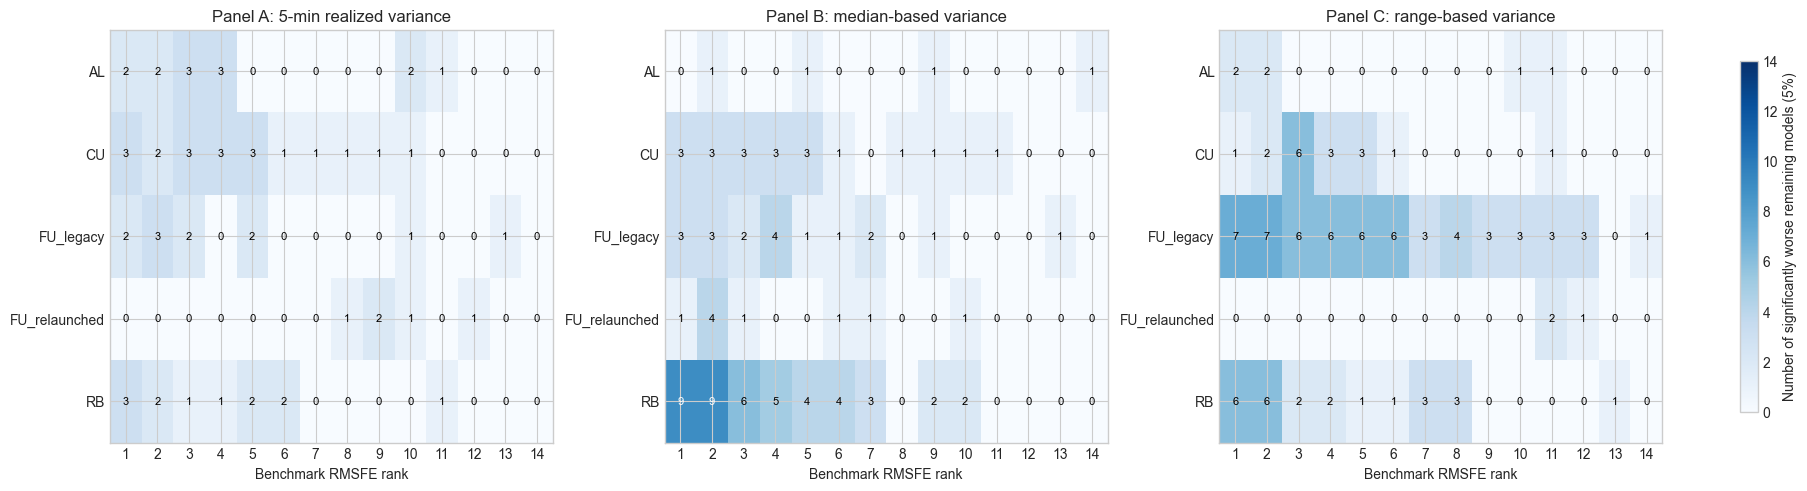

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
for axis, proxy_id in zip(axes, proxy_order):
    heatmap_df = sequential_summary_df.loc[
        sequential_summary_df["proxy_id"].eq(proxy_id)
    ].pivot(
        index="series_id",
        columns="benchmark_rmsfe_rank",
        values="significantly_better_at_5pct",
    )
    heatmap_df = heatmap_df.reindex(index=series_order, columns=range(1, 15))
    image_artist = axis.imshow(
        heatmap_df.to_numpy(dtype=float),
        aspect="auto",
        cmap="Blues",
        vmin=0,
        vmax=14,
    )
    axis.set_title(proxy_panel_label[proxy_id])
    axis.set_xlabel("Benchmark RMSFE rank")
    axis.set_xticks(np.arange(14), labels=np.arange(1, 15))
    axis.set_yticks(np.arange(len(series_order)), labels=series_order)
    for row_index in range(len(series_order)):
        for column_index in range(14):
            cell_value = int(heatmap_df.iloc[row_index, column_index])
            axis.text(
                column_index,
                row_index,
                str(cell_value),
                ha="center",
                va="center",
                fontsize=8,
                color="white" if cell_value >= 8 else "black",
            )
figure.colorbar(
    image_artist,
    ax=axes,
    label="Number of significantly worse remaining models (5%)",
    shrink=0.85,
)
plt.show()


## 13. 独立公式复核与验证门禁

选择一个真实比较，不调用 DM 主函数的内部结果，逐行重新计算中心化、两次 AR(1)、自动带宽、QS 权重、全部滞后加权和、重新着色、标准误与双侧 p 值；同时用损失差取反验证统计量符号严格翻转。其余门禁覆盖固定成果、OOS、代理、模型网格、比较数量、方向和 FU/RB 边界。


In [14]:
manual_result_row = table8_result_df.iloc[0]
manual_loss_matrix_df = loss_matrix_by_group[
    (manual_result_row.proxy_id, manual_result_row.series_id)
]
manual_loss_differential = (
    manual_loss_matrix_df[
        manual_result_row.benchmark_model_id
    ].to_numpy(dtype=np.float64)
    - manual_loss_matrix_df[
        manual_result_row.competing_model_id
    ].to_numpy(dtype=np.float64)
)
manual_observations = len(manual_loss_differential)
manual_mean = float(manual_loss_differential.mean())
manual_centered = manual_loss_differential - manual_mean
manual_prewhitening_ar1 = float(
    np.dot(manual_centered[1:], manual_centered[:-1])
    / np.dot(manual_centered[:-1], manual_centered[:-1])
)
manual_prewhitened = (
    manual_centered[1:]
    - manual_prewhitening_ar1 * manual_centered[:-1]
)
manual_bandwidth_ar1 = float(
    np.dot(manual_prewhitened[1:], manual_prewhitened[:-1])
    / np.dot(manual_prewhitened[:-1], manual_prewhitened[:-1])
)
manual_alpha2 = float(
    4.0
    * manual_bandwidth_ar1**2
    / (1.0 - manual_bandwidth_ar1) ** 4
)
manual_bandwidth = float(
    1.3221 * (len(manual_prewhitened) * manual_alpha2) ** 0.2
)
manual_weighted_cross_product = float(
    np.dot(manual_prewhitened, manual_prewhitened)
)
manual_available_lags = np.arange(1, len(manual_prewhitened))
manual_scaled_lags = manual_available_lags / manual_bandwidth
manual_kernel_argument = 6.0 * np.pi * manual_scaled_lags / 5.0
manual_kernel_weights = (
    25.0
    / (12.0 * np.pi**2 * manual_scaled_lags**2)
    * (
        np.sin(manual_kernel_argument) / manual_kernel_argument
        - np.cos(manual_kernel_argument)
    )
)
manual_lagged_cross_products = np.array(
    [
        np.dot(
            manual_prewhitened[lag:],
            manual_prewhitened[:-lag],
        )
        for lag in manual_available_lags
    ]
)
manual_weighted_cross_product += float(
    2.0
    * np.dot(manual_kernel_weights, manual_lagged_cross_products)
)
manual_long_run_variance = float(
    manual_observations
    / (manual_observations - 1)
    / (1.0 - manual_prewhitening_ar1) ** 2
    * manual_weighted_cross_product
    / manual_observations
)
manual_standard_error = float(
    np.sqrt(manual_long_run_variance / manual_observations)
)
manual_dm_statistic = float(manual_mean / manual_standard_error)
manual_two_sided_p_value = float(
    2.0 * stats.norm.sf(abs(manual_dm_statistic))
)
reversed_test_result = andrews_monahan_dm_test(
    -manual_loss_differential
)

validation_rows = []


def add_gate(gate, passed, evidence):
    validation_rows.append(
        {"gate": gate, "passed": bool(passed), "evidence": str(evidence)}
    )


add_gate(
    "latitude_environment",
    current_python == expected_python,
    current_python,
)
add_gate(
    "fixed_item09_identity_and_hashes",
    success_payload["manifest_sha256"] == sha256_file(manifest_path)
    and artifact_file_audit_df["integrity_passed"].all()
    and upstream_validation_df["passed"].all(),
    f"run_id={fixed_run_id}; files={len(artifact_file_audit_df)}; upstream_gates=27",
)
add_gate(
    "primary_forecast_grid_only",
    len(forecast_panel_df) == 31_200
    and len(primary_forecast_df) == 19_500
    and primary_forecast_df["model_id"].nunique() == 15
    and primary_forecast_df["is_primary"].all()
    and not primary_forecast_df["model_id"].str.contains(
        "no_lookahead", regex=False
    ).any(),
    "31,200 artifact rows loaded; tests use exactly 19,500 primary rows and 15 models",
)
add_gate(
    "forecast_grid_and_oos_counts",
    oos_date_audit_df.set_index("series_id")["oos_days"].to_dict()
    == {"AL": 300, "CU": 300, "FU_legacy": 200, "FU_relaunched": 200, "RB": 300},
    "AL/CU/RB=300; each FU segment=200",
)
add_gate(
    "model_information_precedes_target",
    primary_forecast_df["model_information_end"].lt(
        primary_forecast_df["forecast_date"]
    ).all(),
    "模型估计信息严格早于目标日；primary 的全文季节因子前视性质单独披露",
)
add_gate(
    "three_month_contract_and_session_structure",
    len(target_session_audit_df) == 1_300
    and target_session_audit_df["session_count"].eq(3).all()
    and target_session_audit_df["minute_count"].eq(225).all()
    and target_day_df["delivery_year"].eq(target_delivery_period.year).all()
    and target_day_df["delivery_month"].eq(target_delivery_period.month).all(),
    "1,300 target days; +3 delivery month; 3 day sessions; 225 minutes",
)
add_gate(
    "three_proxies_complete_nonnegative",
    len(volatility_proxy_df) == 1_300
    and all(
        np.isfinite(volatility_proxy_df[proxy_column]).all()
        and volatility_proxy_df[proxy_column].ge(0).all()
        for proxy_column, _, _ in proxy_spec
    ),
    "1,300 days × RV/MedRV/Parkinson; finite and nonnegative",
)
add_gate(
    "loss_and_rmsfe_grid_complete",
    len(primary_loss_df) == 58_500
    and len(primary_rmsfe_df) == 225
    and np.isfinite(primary_loss_df["squared_forecast_error"]).all()
    and np.isfinite(primary_rmsfe_df["rmsfe"]).all(),
    "58,500 losses; 225 primary RMSFE values",
)
add_gate(
    "lowest_rmsfe_benchmarks",
    len(benchmark_df) == 15
    and benchmark_df["evaluation_days"].isin([200, 300]).all(),
    "每个 series × proxy 恰好一个最低 RMSFE 基准",
)
add_gate(
    "table8_comparison_count",
    len(table8_result_df) == 15 * 14
    and table8_result_df.groupby(
        ["proxy_id", "series_id"], observed=True
    ).size().eq(14).all(),
    "15 groups × 14 competitors = 210",
)
add_gate(
    "sequential_comparison_count",
    len(sequential_result_df) == 15 * (15 * 14 // 2)
    and sequential_result_df.groupby(
        ["proxy_id", "series_id"], observed=True
    ).size().eq(105).all(),
    "15 groups × C(15,2) = 1,575",
)
add_gate(
    "rmsfe_order_matches_loss_direction",
    table8_result_df["mean_loss_differential"].le(1e-24).all()
    and sequential_result_df["mean_loss_differential"].le(1e-24).all(),
    "所有比较均为较低 RMSFE 基准减较高 RMSFE 竞争模型，均值不为正",
)
add_gate(
    "hac_outputs_finite_and_admissible",
    np.isfinite(
        sequential_result_df[
            [
                "dm_west_statistic",
                "p_value_two_sided",
                "prewhitening_ar1",
                "bandwidth_ar1",
                "andrews_bandwidth",
                "long_run_variance",
            ]
        ]
    ).all().all()
    and sequential_result_df["p_value_two_sided"].between(0.0, 1.0).all()
    and sequential_result_df["andrews_bandwidth"].ge(0.0).all()
    and sequential_result_df["long_run_variance"].gt(0.0).all(),
    "1,575 HAC results finite; p in [0,1]; bandwidth >= 0; LRV > 0",
)
add_gate(
    "manual_hac_recalculation",
    np.isclose(
        manual_prewhitening_ar1,
        manual_result_row.prewhitening_ar1,
        rtol=1e-13,
        atol=0.0,
    )
    and np.isclose(
        manual_bandwidth,
        manual_result_row.andrews_bandwidth,
        rtol=1e-13,
        atol=0.0,
    )
    and np.isclose(
        manual_long_run_variance,
        manual_result_row.long_run_variance,
        rtol=1e-13,
        atol=0.0,
    )
    and np.isclose(
        manual_dm_statistic,
        manual_result_row.dm_west_statistic,
        rtol=1e-13,
        atol=0.0,
    )
    and np.isclose(
        manual_two_sided_p_value,
        manual_result_row.p_value_two_sided,
        rtol=1e-13,
        atol=0.0,
    ),
    f"manual DM={manual_dm_statistic:.12f}; reported={manual_result_row.dm_west_statistic:.12f}",
)
add_gate(
    "loss_sign_reversal",
    np.isclose(
        reversed_test_result["dm_west_statistic"],
        -manual_result_row.dm_west_statistic,
        rtol=1e-13,
        atol=0.0,
    )
    and np.isclose(
        reversed_test_result["p_value_two_sided"],
        manual_result_row.p_value_two_sided,
        rtol=1e-13,
        atol=0.0,
    ),
    "交换 benchmark/competing 后统计量反号、双侧 p 值不变",
)
rank1_sequential_df = sequential_result_df.loc[
    sequential_result_df["benchmark_rmsfe_rank"].eq(1)
]
table8_sequential_check_df = table8_result_df.merge(
    rank1_sequential_df,
    on=[
        "proxy_id",
        "series_id",
        "benchmark_model_id",
        "competing_model_id",
    ],
    suffixes=("_table8", "_sequential"),
    validate="one_to_one",
)
add_gate(
    "table8_equals_first_sequential_rows",
    len(table8_sequential_check_df) == 210
    and np.allclose(
        table8_sequential_check_df["dm_west_statistic_table8"],
        table8_sequential_check_df["dm_west_statistic_sequential"],
        rtol=0.0,
        atol=0.0,
    ),
    "Table 8 的 210 个比较与顺序表 rank=1 完全一致",
)
add_gate(
    "fu_segments_and_rb_separate",
    target_day_df.loc[
        target_day_df["series_id"].eq("FU_legacy"), "forecast_date"
    ].max()
    == pd.Timestamp("2011-09-30")
    and target_day_df.loc[
        target_day_df["series_id"].eq("FU_relaunched"), "forecast_date"
    ].min()
    > pd.Timestamp("2020-01-02")
    and table8_result_df.loc[
        table8_result_df["series_id"].eq("RB")
    ].shape[0]
    == 42,
    "FU 两段不连接；RB 以 3 个代理 × 14 个比较单列",
)

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
assert validation_df["passed"].all(), validation_df.loc[
    ~validation_df["passed"]
]
print(f"全部 {len(validation_df)} 项门禁通过。")


,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,fixed_item09_identity_and_hashes,True,run_id=eaf4757d3488c2b7; files=4; upstream_gates=27
2,primary_forecast_grid_only,True,"31,200 artifact rows loaded; tests use exactly 19,500 primary rows and 15 models"
3,forecast_grid_and_oos_counts,True,AL/CU/RB=300; each FU segment=200
4,model_information_precedes_target,True,模型估计信息严格早于目标日；primary 的全文季节因子前视性质单独披露
5,three_month_contract_and_session_structure,True,"1,300 target days; +3 delivery month; 3 day sessions; 225 minutes"
6,three_proxies_complete_nonnegative,True,"1,300 days × RV/MedRV/Parkinson; finite and nonnegative"
7,loss_and_rmsfe_grid_complete,True,"58,500 losses; 225 primary RMSFE values"
8,lowest_rmsfe_benchmarks,True,每个 series × proxy 恰好一个最低 RMSFE 基准
9,table8_comparison_count,True,15 groups × 14 competitors = 210


全部 17 项门禁通过。


## 14. 结果解释与限制

下列计数只概括当前湖仓样本。显著性仍是逐对检验，最低 RMSFE 基准本身由同一 OOS 样本选出，存在多重比较和数据挖掘问题；第 12 项 SPA 才负责统一处理这一层不确定性。


In [15]:
table8_summary_df = (
    table8_result_df.assign(
        benchmark_better_1pct=lambda frame: (
            frame["dm_west_statistic"].lt(0)
            & frame["p_value_two_sided"].lt(0.01)
        ),
        benchmark_better_5pct=lambda frame: (
            frame["dm_west_statistic"].lt(0)
            & frame["p_value_two_sided"].lt(0.05)
        ),
        benchmark_better_10pct=lambda frame: (
            frame["dm_west_statistic"].lt(0)
            & frame["p_value_two_sided"].lt(0.10)
        ),
        competing_better_5pct=lambda frame: (
            frame["dm_west_statistic"].gt(0)
            & frame["p_value_two_sided"].lt(0.05)
        ),
    )
    .groupby("proxy_id", observed=True)
    .agg(
        comparisons=("competing_model_id", "size"),
        benchmark_better_1pct=("benchmark_better_1pct", "sum"),
        benchmark_better_5pct=("benchmark_better_5pct", "sum"),
        benchmark_better_10pct=("benchmark_better_10pct", "sum"),
        competing_better_5pct=("competing_better_5pct", "sum"),
        median_dm_statistic=("dm_west_statistic", "median"),
    )
    .reset_index()
)
strongest_table8_row = table8_result_df.loc[
    table8_result_df["dm_west_statistic"].idxmin()
]
first_rank_summary_df = sequential_summary_df.loc[
    sequential_summary_df["benchmark_rmsfe_rank"].eq(1)
].sort_values(["proxy_id", "series_id"])

display(Markdown("### 最低 RMSFE 基准的配对显著性计数"))
display(table8_summary_df.round(3))
display(Markdown("### 每组第一名在 5% 水平显著优于多少个其余模型"))
display(
    first_rank_summary_df[
        [
            "proxy_id",
            "series_id",
            "benchmark_model_id",
            "remaining_models",
            "significantly_better_at_5pct",
        ]
    ]
)

total_benchmark_better_5pct = int(
    (
        table8_result_df["dm_west_statistic"].lt(0)
        & table8_result_df["p_value_two_sided"].lt(0.05)
    ).sum()
)
statistically_indistinguishable_5pct = int(
    table8_result_df["p_value_two_sided"].ge(0.05).sum()
)
display(
    Markdown(
        f'''**本湖仓样本结论。** 最低 RMSFE 基准面对 210 个竞争模型时，有 {total_benchmark_better_5pct} 个比较在 5% 双侧水平下显著支持基准更优，另有 {statistically_indistinguishable_5pct} 个比较不足以拒绝等预测能力。最强的负向统计量来自 `{strongest_table8_row['proxy_id']} / {strongest_table8_row['series_id']}`：`{strongest_table8_row['benchmark_model_id']}` 对 `{strongest_table8_row['competing_model_id']}`，DM–West = `{strongest_table8_row['dm_west_statistic']:.3f}`。这些结果刻画的是当前固定日盘样本中的成对预测差异，不是论文 GTA 数值的原样复制。'''
    )
)
display(
    Markdown(
        '''**限制。** 三个代理并非潜在真实条件方差；平方损失对极端日敏感。论文 primary 季节因子按全文样本估计，含明确前视信息，本项为保持论文基线只检验这 15 个 primary 模型；第 10 项发现的不稳定无前视敏感性流被明确排除。AR(1) 预白化、QS 核、自动带宽和有限样本调整属于论文未披露的软件细节，因此结果应与项目冻结口径绑定解释。最低 RMSFE 的事后选择和大量配对检验会改变整体错误率，下一项必须用 SPA 检验做模型集合层面的综合。'''
    )
)


### 最低 RMSFE 基准的配对显著性计数

,proxy_id,comparisons,benchmark_better_1pct,benchmark_better_5pct,benchmark_better_10pct,competing_better_5pct,median_dm_statistic
0,MedRV,70,4,16,23,0,-1.297
1,Parkinson,70,11,16,27,0,-1.470
2,RV_5min,70,1,10,18,0,-1.214


### 每组第一名在 5% 水平显著优于多少个其余模型

,proxy_id,series_id,benchmark_model_id,remaining_models,significantly_better_at_5pct
0,MedRV,AL,FIGARCH_60min,14,0
14,MedRV,CU,FIGARCH_30min,14,3
28,MedRV,FU_legacy,ARFIMA_15min,14,3
42,MedRV,FU_relaunched,FIGARCH_60min,14,1
56,MedRV,RB,ARFIMA_15min,14,9
70,Parkinson,AL,GARCH_15min,14,2
84,Parkinson,CU,FIGARCH_60min,14,1
98,Parkinson,FU_legacy,FIGARCH_Daily,14,7
112,Parkinson,FU_relaunched,GARCH_60min,14,0
126,Parkinson,RB,FIGARCH_60min,14,6


**本湖仓样本结论。** 最低 RMSFE 基准面对 210 个竞争模型时，有 42 个比较在 5% 双侧水平下显著支持基准更优，另有 168 个比较不足以拒绝等预测能力。最强的负向统计量来自 `Parkinson / RB`：`FIGARCH_60min` 对 `GARCH_Daily`，DM–West = `-3.938`。这些结果刻画的是当前固定日盘样本中的成对预测差异，不是论文 GTA 数值的原样复制。

**限制。** 三个代理并非潜在真实条件方差；平方损失对极端日敏感。论文 primary 季节因子按全文样本估计，含明确前视信息，本项为保持论文基线只检验这 15 个 primary 模型；第 10 项发现的不稳定无前视敏感性流被明确排除。AR(1) 预白化、QS 核、自动带宽和有限样本调整属于论文未披露的软件细节，因此结果应与项目冻结口径绑定解释。最低 RMSFE 的事后选择和大量配对检验会改变整体错误率，下一项必须用 SPA 检验做模型集合层面的综合。